<a href="https://colab.research.google.com/github/FareedaAbdelaal/ML-55-9988/blob/main/Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


In [6]:
#Upload Datasets
from google.colab import files

uploaded = files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [7]:
# LOAD THE DATASET

train_df = pd.read_csv("train.csv")

test_df = pd.read_csv("test.csv")

print("First 5 rows of Training Dataset:")
display(train_df.head())

print("\nTraining Dataset Information:")
train_df.info()

print("\nStatistical Summary:")
display(train_df.describe())


First 5 rows of Training Dataset:


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury



Training Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BA

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


The dataset contains both numerical and categorical features related to car crashes. The `info()` output shows that the training dataset contains 4000 rows and 19 columns. Most features are complete, while the `Distraction Level` column contains missing values that will be handled during preprocessing.

The statistical summary provides information about the distribution and range of numerical features such as crash speed, driver age, and visibility distance. Since the numerical features have different scales, feature scaling will be applied later.

Training Dataset Shape: (4000, 19)
Testing Dataset Shape: (1000, 19)

Missing Values in Training Dataset:


,0
Crash Speed (km/h),0
Impact Angle (degrees),0
Airbag Deployed,0
Seatbelt Used,0
Weather Conditions,0
Road Conditions,0
Crash Type,0
Vehicle Type,0
Vehicle Age (years),0
Brake Condition,0


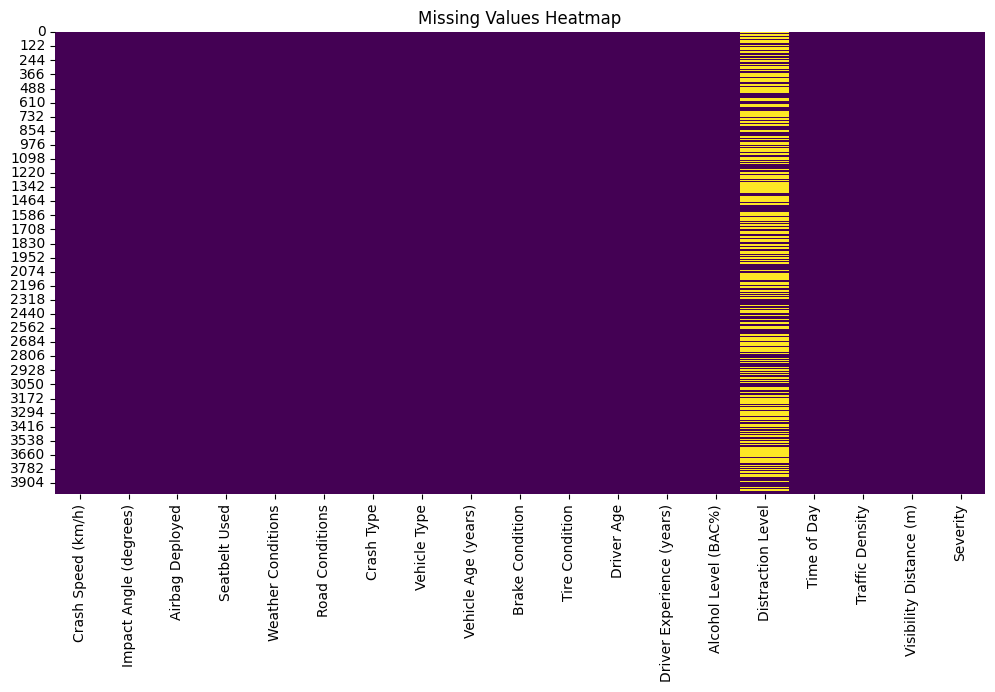

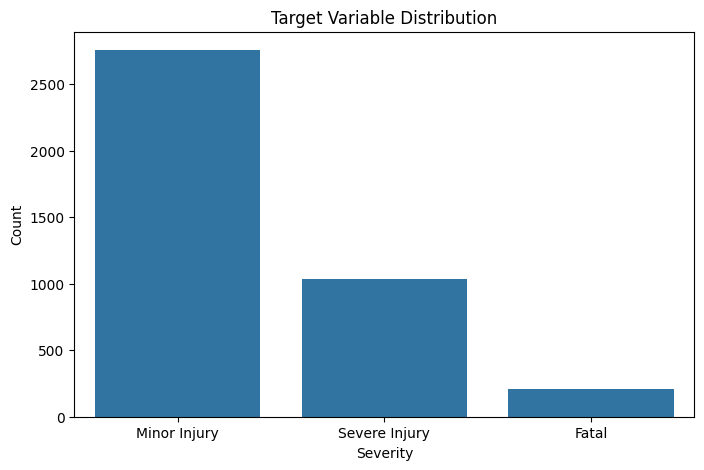


Class Distribution Percentage:


,proportion
Severity,
Minor Injury,68.90
Severe Injury,25.95
Fatal,5.15


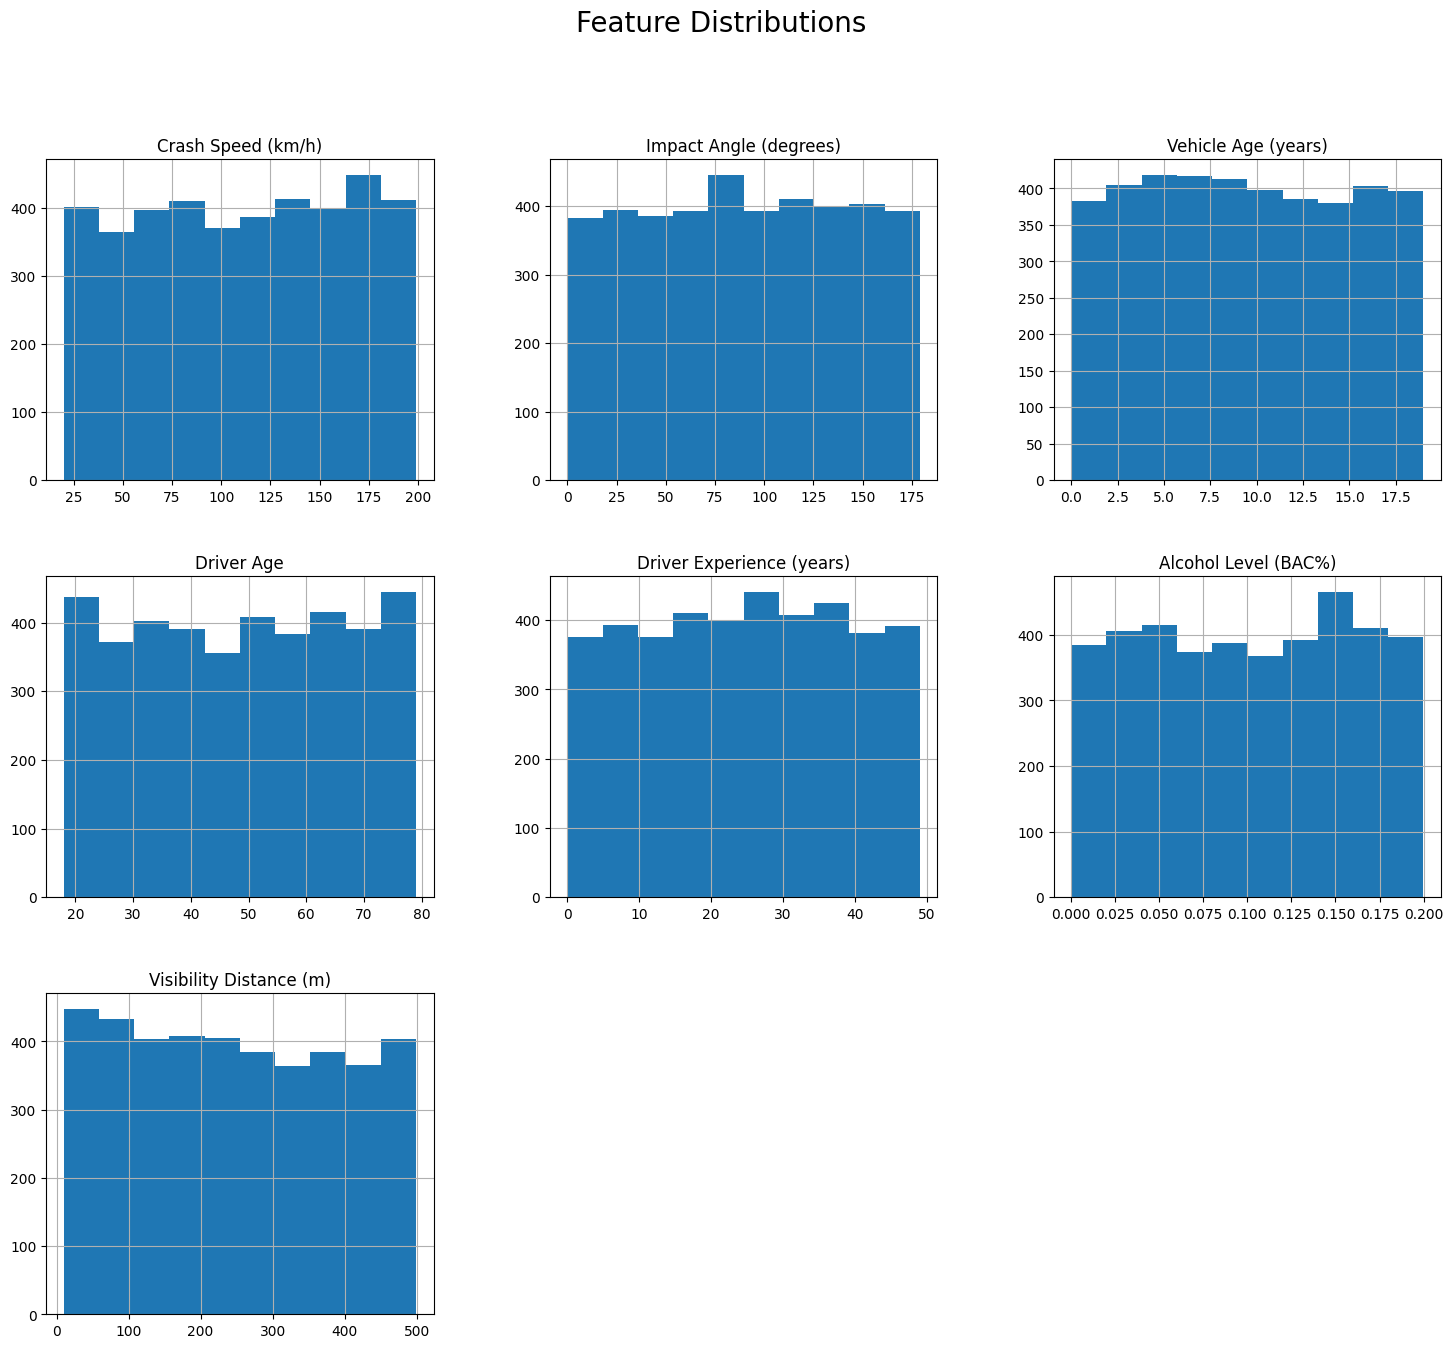

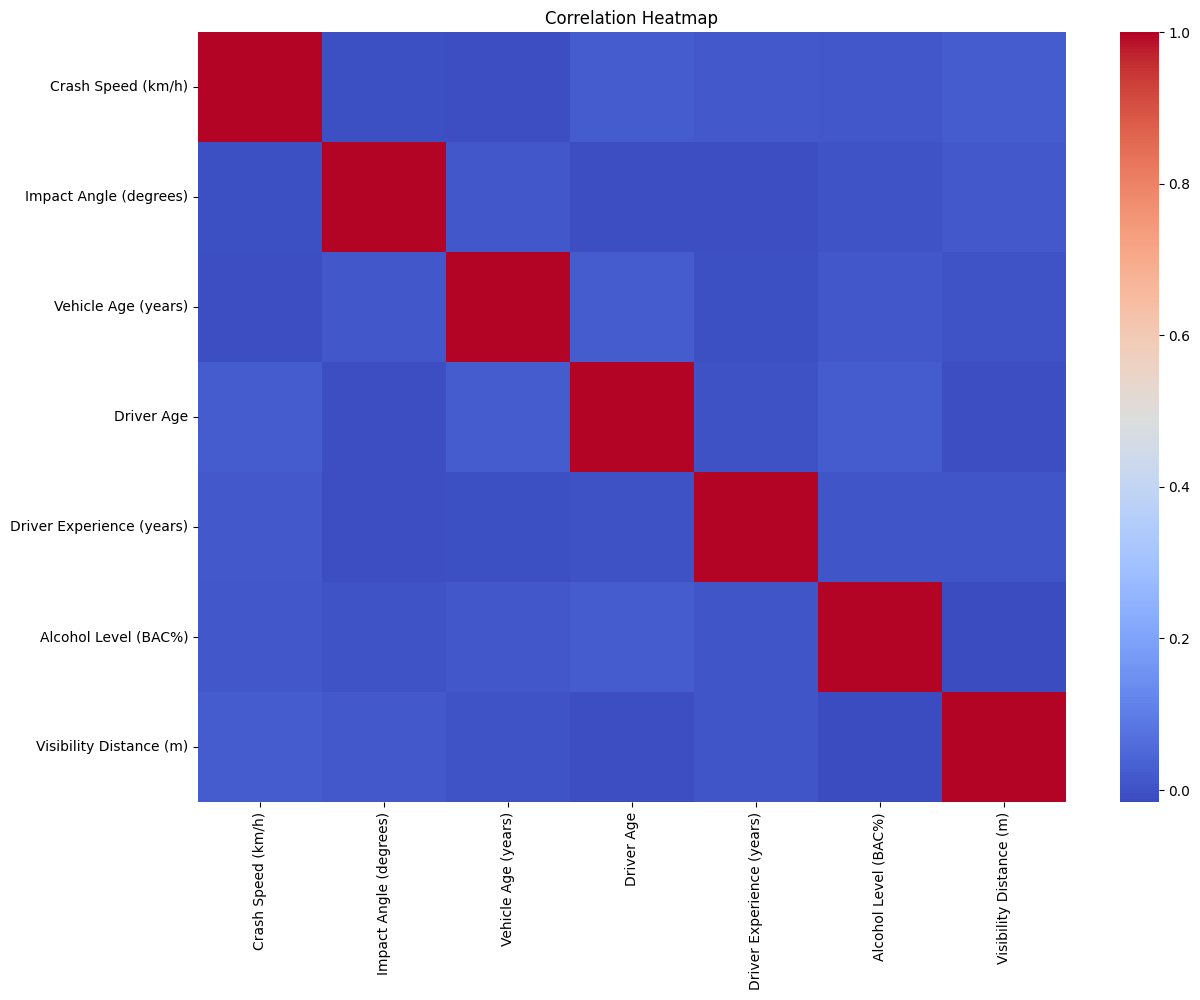

In [8]:
# 4. EXPLORATORY DATA ANALYSIS (EDA)

# Check dataset shape

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)


# Check missing values

print("\nMissing Values in Training Dataset:")
display(train_df.isnull().sum())


# Visualize missing values

plt.figure(figsize=(12,6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Target variable distribution


TARGET_COLUMN = 'Severity'

plt.figure(figsize=(8,5))
sns.countplot(x=TARGET_COLUMN, data=train_df)

plt.title("Target Variable Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()


# Check class balance percentages

print("\nClass Distribution Percentage:")

class_percentages = (
    train_df[TARGET_COLUMN]
    .value_counts(normalize=True) * 100
)

display(class_percentages)


# Numerical feature distributions

# Plot histograms for all numerical columns
train_df.hist(figsize=(18,15))

plt.suptitle("Feature Distributions", fontsize=20)

plt.show()


# Correlation Heatmap


# Select only numerical columns
numerical_df = train_df.select_dtypes(include=np.number)

# Compute correlation matrix
correlation_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to better understand the dataset structure, identify missing values, analyze feature distributions, and examine relationships between variables before applying machine learning models.

The training dataset contains 4000 rows and 19 columns, while the testing dataset contains 1000 rows and 19 columns.

The missing values analysis shows that almost all features are complete except for the `Distraction Level` feature, which contains 2360 missing values. The heatmap clearly highlights these missing entries. These missing values will be handled during the preprocessing stage.

The target variable distribution indicates that the dataset is imbalanced. Most crash cases belong to the `Minor Injury` class (68.9%), followed by `Severe Injury` (25.95%), while `Fatal` cases represent only 5.15% of the dataset. This imbalance may negatively affect the ability of some machine learning models to correctly classify minority classes.

The feature distribution plots illustrate the spread of numerical variables such as crash speed, impact angle, driver age, vehicle age, alcohol level, and visibility distance. Most numerical features appear reasonably distributed without significant outliers.

Finally, the correlation heatmap shows generally weak correlations between numerical features, suggesting that crash severity prediction depends on combinations of multiple variables rather than a single strongly correlated feature.


In [9]:
# DATA PREPROCESSING

# Handle Missing Values


# Fill numerical missing values with median
for col in train_df.select_dtypes(include=np.number).columns:
    train_df[col].fillna(train_df[col].median(), inplace=True)

for col in test_df.select_dtypes(include=np.number).columns:
    test_df[col].fillna(test_df[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in train_df.select_dtypes(include='object').columns:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)

for col in test_df.select_dtypes(include='object').columns:
    test_df[col].fillna(test_df[col].mode()[0], inplace=True)


# Encode Categorical Variables

# Label Encoding converts text categories into numbers

label_encoders = {}

categorical_columns = train_df.select_dtypes(include='object').columns

for col in categorical_columns:

    le = LabelEncoder()

    # Combine train and test values to avoid unseen labels
    combined_data = pd.concat([
        train_df[col],
        test_df[col]
    ], axis=0).astype(str)

    le.fit(combined_data)

    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

    label_encoders[col] = le


In this section, missing values were handled and categorical features were converted into numerical form to prepare the dataset for machine learning models.

Numerical missing values were replaced using the median, while categorical missing values were filled using the mode. Label Encoding was then applied to transform categorical variables into numerical values that can be processed by classification algorithms.



In [10]:
# SEPARATE FEATURES AND TARGET

# X contains input features
# y contains target labels

X = train_df.drop(TARGET_COLUMN, axis=1)

y = train_df[TARGET_COLUMN]



In this step, the dataset was divided into:
- input features (`X`) used for training the models,
- and the target variable (`y`) representing the crash severity class to be predicted.

In [11]:
# TRAIN-TEST SPLIT

# Split dataset into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Validation Features Shape:", X_val.shape)



Training Features Shape: (3200, 18)
Validation Features Shape: (800, 18)


# Train-Test Split

The dataset was divided into training and validation sets using an 80-20 split. The training set contains 3200 samples and 18 features, while the validation set contains 800 samples and 18 features.

Stratified sampling was applied using `stratify=y` to preserve the original class distribution in both datasets. This helps ensure that the machine learning models are evaluated fairly, especially since the dataset is imbalanced.

In [12]:
# FEATURE SCALING


scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation data
X_val_scaled = scaler.transform(X_val)



================ LOGISTIC REGRESSION ================

Accuracy: 0.68875

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      1.00      0.82       551
           2       0.00      0.00      0.00       208

    accuracy                           0.69       800
   macro avg       0.23      0.33      0.27       800
weighted avg       0.47      0.69      0.56       800



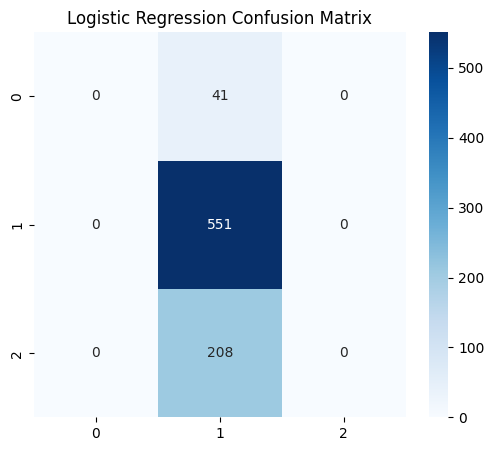

In [13]:
# LOGISTIC REGRESSION

print("\n================ LOGISTIC REGRESSION ================\n")

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_val_scaled)

# Calculate accuracy
lr_accuracy = accuracy_score(y_val, lr_predictions)

print("Accuracy:", lr_accuracy)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_val, lr_predictions))

# Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_val, lr_predictions),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()


# Logistic Regression Analysis

The Logistic Regression model achieved an accuracy of 68.88%. Although this accuracy appears relatively high, the classification report and confusion matrix show that the model mainly predicted the majority class (`Minor Injury`).

The model achieved very high recall for class 1 but failed to correctly classify the minority classes (`Fatal` and `Severe Injury`), resulting in precision and recall values close to zero for those categories.

This behavior is mainly caused by the imbalance in the dataset, where most crash cases belong to the `Minor Injury` class. As a result, the model became biased toward predicting the majority class to maximize overall accuracy.

The confusion matrix clearly shows that nearly all samples were classified as class 1, indicating poor performance in detecting minority severity categories.


================ KNN CLASSIFIER ================

Accuracy: 0.61875

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.68      0.87      0.76       551
           2       0.19      0.09      0.12       208

    accuracy                           0.62       800
   macro avg       0.29      0.32      0.29       800
weighted avg       0.52      0.62      0.56       800



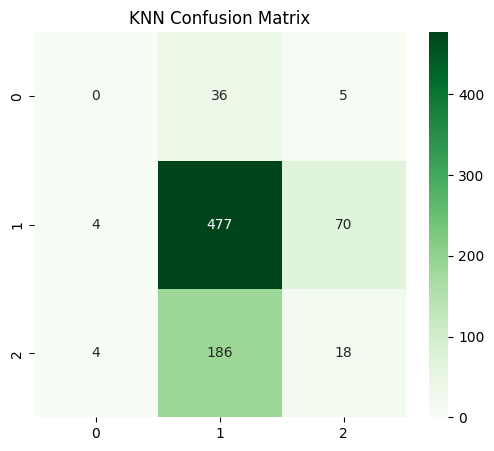

In [14]:
# K-NEAREST NEIGHBORS (KNN)

print("\n================ KNN CLASSIFIER ================\n")

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Make predictions
knn_predictions = knn_model.predict(X_val_scaled)

# Calculate accuracy
knn_accuracy = accuracy_score(y_val, knn_predictions)

print("Accuracy:", knn_accuracy)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_val, knn_predictions))

# Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_val, knn_predictions),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("KNN Confusion Matrix")

plt.show()


# K-Nearest Neighbors (KNN) Analysis

The KNN classifier achieved an accuracy of 61.88%, which is lower than the Logistic Regression model. However, the confusion matrix and classification report show that KNN was able to classify some minority class samples, especially class 2, unlike Logistic Regression.

The model achieved good recall for the majority class (`Minor Injury`) but struggled to correctly classify minority classes, resulting in low precision and recall values for those categories.

The confusion matrix shows that many samples from the minority classes were incorrectly classified as the majority class. This indicates that the dataset imbalance still affected the model’s performance.

Overall, KNN demonstrated slightly better minority class detection compared to Logistic Regression, but its overall classification performance remained limited.


================ DECISION TREE ================

Accuracy: 0.635

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      0.88      0.77       551
           2       0.26      0.12      0.16       208

    accuracy                           0.64       800
   macro avg       0.31      0.33      0.31       800
weighted avg       0.54      0.64      0.57       800



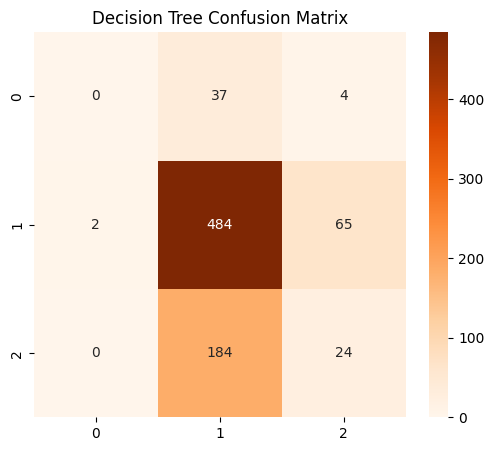

In [15]:
#DECISION TREE

print("\n================ DECISION TREE ================\n")

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_model.predict(X_val)

# Calculate accuracy
dt_accuracy = accuracy_score(y_val, dt_predictions)

print("Accuracy:", dt_accuracy)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_val, dt_predictions))

# Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_val, dt_predictions),
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Decision Tree Confusion Matrix")

plt.show()


# Decision Tree Analysis

The Decision Tree classifier achieved an accuracy of 63.5%, which is slightly higher than the KNN model. Compared to Logistic Regression and Naïve Bayes, the Decision Tree showed better ability to classify minority classes.

The classification report indicates improved performance for class 2 (`Fatal`) with higher precision and recall values compared to previous models. However, the model still struggled to correctly classify class 0 due to the imbalance in the dataset.

The confusion matrix shows that the model predicted samples across multiple classes instead of focusing mainly on the majority class. This demonstrates that the Decision Tree classifier produced more balanced predictions.

Overall, the Decision Tree model provided a better balance between overall accuracy and minority class detection, making it one of the more effective models in this project.


================ RANDOM FOREST ================

Accuracy: 0.68625

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      1.00      0.81       551
           2       0.00      0.00      0.00       208

    accuracy                           0.69       800
   macro avg       0.23      0.33      0.27       800
weighted avg       0.47      0.69      0.56       800



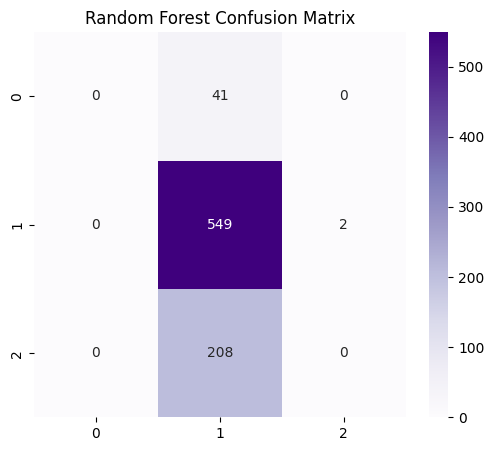

In [16]:
#RANDOM FOREST

print("\n================ RANDOM FOREST ================\n")

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=15
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_val)

# Calculate accuracy
rf_accuracy = accuracy_score(y_val, rf_predictions)

print("Accuracy:", rf_accuracy)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_val, rf_predictions))

# Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_val, rf_predictions),
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Random Forest Confusion Matrix")

plt.show()


# Random Forest Analysis

The Random Forest classifier achieved an accuracy of 68.63%, making it one of the highest performing models in terms of overall accuracy.

However, the classification report and confusion matrix show that the model mainly predicted the majority class (`Minor Injury`) and struggled to correctly classify the minority classes. Precision and recall values for classes 0 and 2 were extremely low, indicating poor minority class detection.

The confusion matrix shows that almost all validation samples were classified as class 1, which demonstrates that the model became biased toward the dominant class due to the imbalance in the dataset.

Although Random Forest achieved high accuracy, the model did not generalize well across all severity categories. This highlights that accuracy alone is not always sufficient for evaluating imbalanced classification problems.


================ NAIVE BAYES ================

Accuracy: 0.68875

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.69      1.00      0.82       551
           2       0.00      0.00      0.00       208

    accuracy                           0.69       800
   macro avg       0.23      0.33      0.27       800
weighted avg       0.47      0.69      0.56       800



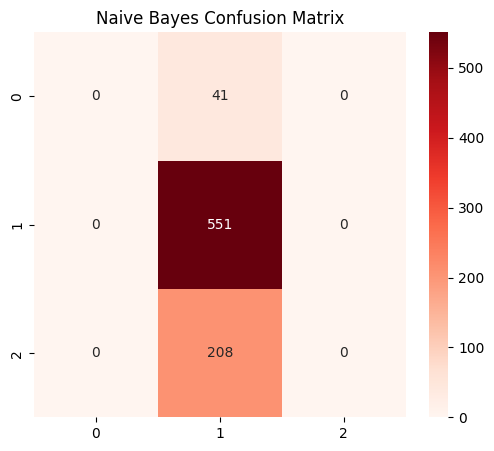

In [17]:
# NAIVE BAYES

print("\n================ NAIVE BAYES ================\n")

# Create Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train_scaled, y_train)

# Make predictions
nb_predictions = nb_model.predict(X_val_scaled)

# Calculate accuracy
nb_accuracy = accuracy_score(y_val, nb_predictions)

print("Accuracy:", nb_accuracy)

# Display classification report
print("\nClassification Report:")
print(classification_report(y_val, nb_predictions))

# Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_val, nb_predictions),
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("Naive Bayes Confusion Matrix")

plt.show()


# Naïve Bayes Analysis

The Naïve Bayes classifier achieved an accuracy of 68.88%, which is similar to the Logistic Regression model and among the highest accuracy scores obtained in this project.

However, the classification report and confusion matrix reveal that the model heavily favored the majority class (`Minor Injury`) and failed to correctly classify the minority classes. Precision and recall values for classes 0 and 2 were close to zero, indicating very poor performance for minority class prediction.

The confusion matrix shows that nearly all validation samples were classified as class 1, demonstrating that the dataset imbalance strongly affected the model’s behavior.

Although the model achieved high overall accuracy, its performance across all severity categories was unbalanced. This shows that accuracy alone is not enough to evaluate models on imbalanced datasets.


================ MODEL COMPARISON ================



,Model,Accuracy
0,Logistic Regression,0.68875
4,Naive Bayes,0.68875
3,Random Forest,0.68625
2,Decision Tree,0.63500
1,KNN,0.61875


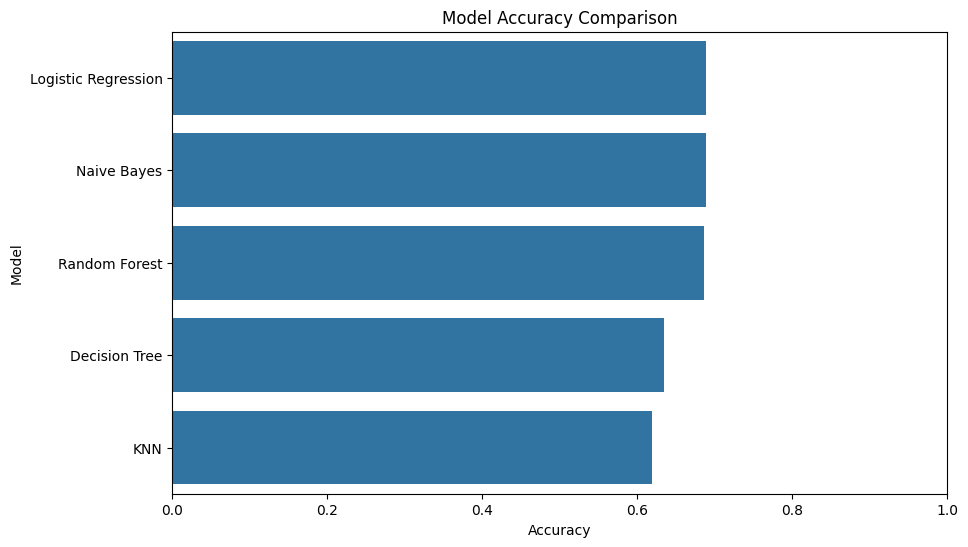

In [18]:
# MODEL COMPARISON

# Create comparison table
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'Naive Bayes'
    ],
    'Accuracy': [
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        nb_accuracy
    ]
})

# Sort by highest accuracy
model_results = model_results.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n================ MODEL COMPARISON ================\n")

display(model_results)


# ------------------------------------------------------------
# Visualize model comparison
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=model_results
)

plt.title("Model Accuracy Comparison")

plt.xlim(0,1)

plt.show()


# Model Comparison

The performance of all implemented machine learning models was compared using accuracy scores.

Logistic Regression and Naïve Bayes achieved the highest accuracy values at approximately 68.88%, followed closely by Random Forest with 68.63%. Decision Tree achieved moderate performance with an accuracy of 63.5%, while KNN produced the lowest accuracy at 61.88%.

Although Logistic Regression and Naïve Bayes achieved the highest overall accuracy, the confusion matrices and classification reports showed that these models mainly predicted the majority class and struggled to correctly classify minority classes.

The Decision Tree model demonstrated more balanced predictions across different severity categories, despite having slightly lower overall accuracy.

Overall, the results show that accuracy alone is not sufficient for evaluating imbalanced datasets, and additional metrics such as precision, recall, and F1-score are important for understanding true model performance.

In [19]:
# BEST MODEL SELECTION

# Get best model based on highest accuracy
best_model = model_results.iloc[0]

print("\nBest Performing Model:")
print(best_model)



Best Performing Model:
Model       Logistic Regression
Accuracy                0.68875
Name: 0, dtype: object


# Best Model Selection

Based on the accuracy scores, Logistic Regression was selected as the best performing model with an accuracy of 68.88%.

However, despite achieving the highest overall accuracy, the model struggled to correctly classify minority classes due to the imbalance in the dataset. Most predictions were concentrated on the majority class (`Minor Injury`).

Therefore, while Logistic Regression achieved the best accuracy, the Decision Tree model demonstrated more balanced predictions across different severity categories.

Possible Future Improvements:

- Hyperparameter tuning
- Feature engineering
- Cross-validation
- Trying advanced boosting models


# Conclusion

In this project, several machine learning classification models were implemented to predict car crash severity using crash-related features. The project included data preprocessing, exploratory data analysis, model training, and performance evaluation.

Among all models, Logistic Regression and Naïve Bayes achieved the highest accuracy of 68.88%, followed closely by Random Forest with 68.63%. Decision Tree achieved 63.5% accuracy, while KNN produced the lowest accuracy of 61.88%.

The results also showed that the dataset was imbalanced, which affected the ability of some models to correctly classify minority classes such as Fatal injuries. Overall, the project demonstrated the importance of preprocessing, model comparison, and evaluation when building machine learning classification systems.